# Исследование рынка общественного питания Москвы

- Автор: Ненашева Виктория
- Дата: 27.09.2025 г.

<a id="Цели-и-задачи-проекта"></a>
### Цели и задачи проекта

<font color='#777778'>Цель проекта — провести исследовательский анализ рынка заведений общественного питания Москвы (по данным на лето 2022 года), чтобы помочь инвесторам фонда Shut Up and Take My Money определить наиболее перспективный формат заведения (кафе, ресторан, бар и др.), а также подобрать подходящее расположение и ценовую категорию.

Задачи исследования:

1. Изучить структуру рынка общественного питания Москвы.

2. Выявить наиболее популярные категории заведений.

3. Оценить распределение заведений по административным округам.

4. Изучить ценовые сегменты и средние чеки.

5. Выявить особенности сетевых и несетевых заведений.

6. Подготовить общий аналитический портрет рынка для принятия инвестиционных решений.</font>

<a id="Описание-данных"></a>
### Описание данных

<font color='#777778'>В работе используются два датасета:

`/datasets/rest_info.csv` — *информация о заведениях общественного питания Москвы:*

`name` — название заведения;

`address` — адрес заведения;

`district` — административный район (например, Центральный административный округ);

`category` — категория заведения (кафе, ресторан, бар, пиццерия и т.д.);

`hours` — информация о днях и часах работы;

`rating` — рейтинг заведения по данным Яндекс Карт (0–5.0);

`chain` — признак сетевого заведения (0 — не сеть, 1 — сеть);

`seats` — количество посадочных мест.

`/datasets/rest_price.csv` — *данные о ценах:*

`price` — категория цен (ниже среднего, средние, выше среднего и др.);

`avg_bill` — строка с диапазоном цен (например: «Средний счёт: 1000–1500 ₽»);

`middle_avg_bill` — числовое значение медианы «Среднего счёта»;

`middle_coffee_cup` — числовое значение медианы стоимости чашки капучино.</font>

<a id="Содержимое-проекта"></a>
### Содержимое проекта

<font color='#777778'> 0.1. [Цели и задачи проекта](#Цели-и-задачи-проекта)  
0.2. [Описание данных](#Описание-данных)  
0.3. [Содержимое проекта](#Содержимое-проекта)  

1. [Загрузка данных и знакомство с ними](#Загрузка-данных-и-знакомство-с-ними)  
 1.1. [Промежуточный вывод](#Промежуточный-вывод)  
 1.2. [Подготовка единого датафрейма](#Подготовка-единого-датафрейма)  

2. [Предобработка данных](#Предобработка-данных)  
 2.1. [Промежуточный вывод](#Промежуточный-вывод-1)  

3. [Исследовательский анализ данных](#Исследовательский-анализ-данных)  
 3.1. [Категории заведений](#Категории-заведений)  
 3.2. [Административные районы Москвы](#Административные-районы-Москвы)  
 3.3. [Сетевые и несетевые заведения](#Сетевые-и-несетевые-заведения)  
 3.4. [Количество посадочных мест](#Количество-посадочных-мест)  
 3.5. [Рейтинг заведений](#Рейтинг-заведений)  
 3.6. [Корреляция рейтингов с другими признаками](#Корреляция-рейтингов-с-другими-признаками)  
 3.7. [Популярные сети Москвы](#Популярные-сети-Москвы)  
 3.8. [Средний чек по районам Москвы](#Средний-чек-по-районам-Москвы)  
 3.9. [Промежуточный вывод](#Промежуточный-вывод-2)  

4. [Итоговый вывод и рекомендации](#Итоговый-вывод-и-рекомендации)  
 4.1. [Общий обзор проделанной работы](#Общий-обзор-проделанной-работы)  
 4.2. [Основные выводы по результатам анализа](#Основные-выводы-по-результатам-анализа)  
 4.3. [Рекомендации для заказчика](#Рекомендации-для-заказчика)</font>

<a id="Загрузка-данных-и-знакомство-с-ними"></a>
## Загрузка данных и знакомство с ними

- Загружаем данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`. Предварительно выгрузим все необходимые для работы библитеки.

In [2]:
pip install phik -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik 

In [3]:
df_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')

In [4]:
df_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [5]:
df_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

In [6]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


- Познакомимся с данными и изучим общую информацию о них.

In [7]:
df_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [8]:
df_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [9]:
display(df_info)

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0
...,...,...,...,...,...,...,...,...,...
8401,0342ad1a45ed41ba89dcba246a8267e5,Суши Мания,кафе,"Москва, Профсоюзная улица, 56",Юго-Западный административный округ,"ежедневно, 09:00–02:00",4.4,0,86.0
8402,ee6bb7c3650e47bd8186fca08eda1091,Миславнес,кафе,"Москва, Пролетарский проспект, 19, корп. 1",Южный административный округ,"ежедневно, 08:00–22:00",4.8,0,150.0
8403,62e8c64d4c89467aba608e39ef87616b,Самовар,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",3.9,0,150.0
8404,06a0db5ecd4842d48cd6350aa923e297,Чайхана Sabr,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,150.0


In [10]:
display(df_price)

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN
...,...,...,...,...,...
4053,962800540173458486f3c465437c2d8b,средние,Цена бокала пива:от 140 ₽,NaN,NaN
4054,4277890d659341848d7051cbf2e51f51,выше среднего,Средний счёт:1000–1500 ₽,1250.0,NaN
4055,026cbc478f9b4c3294a83458dcd89982,средние,NaN,NaN,NaN
4056,71cc394927204d45b81c3a91edb47955,NaN,Средний счёт:50–250 ₽,150.0,NaN


<a id="ЗПромежуточный-вывод"></a>
### Промежуточный вывод

- **Объём данных**:  
  - В датасете `rest_info` содержится **8406 записей** (9 колонок).  
  - В датасете `rest_price` — **4058 записей** (5 колонок).  

- **Соответствие описанию**:  
  - Данные соответствуют заявленному описанию:  
    - `rest_info` содержит информацию о заведениях (название, категория, адрес, район, режим работы, рейтинг, принадлежность к сети, количество мест).  
    - `rest_price` содержит данные о ценах (категория, средний счёт, стоимость кофе).  

- **Пропуски**:  
  - В `rest_info`:  
    - `hours` — **536 пропусков** (~6%).  
    - `seats` — **3611 пропусков** (~43%).  
  - В `rest_price`:  
    - `price` — **743 пропуска** (~18%).  
    - `avg_bill` — **242 пропуска** (~6%).  
    - `middle_avg_bill` — **909 пропусков** (~22%).  
    - `middle_coffee_cup` — **3523 пропуска** (~87%).  

- **Типы данных**:  
  - В целом корректные: строки (`object`) для текстовых полей, числа (`float64`, `int64`) для рейтинга, сетевого признака и числовых значений.  
  - Поле `avg_bill` представлено в текстовом формате с диапазонами и символами ₽ — требуется преобразование в числовой формат.  

- **Особенности для предобработки**:  
  - Существенные пропуски в `seats` и `middle_coffee_cup`.  
  - Данные о ценах (`price`, `avg_bill`) частично текстовые и требуют очистки.  
  - При объединении таблиц (`rest_info` и `rest_price`) часть заведений останется без ценовой информации.  
  - Возможны дубли по названиям из-за наличия сетевых заведений — стоит учитывать признак `chain`.  

<a id="Подготовка-единого-датафрейма"></a>
### Подготовка единого датафрейма

- Объединим данные двух датасетов в один, с которым продолжим работу.

In [11]:
df = df_info.merge(df_price, on='id', how='left')

print(df.shape)
df.head()

(8406, 13)


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


- Итоговый датафрейм содержит **8406 записей** и **13 колонок**.  
- Все заведения из `rest_info` сохранены, а ценовые признаки добавлены из `rest_price`.  
- Данные о ценах присутствуют примерно для **половины заведений** (около 48%).  
- В объединённом датафрейме остаются пропуски по ценовым признакам (`price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`), что необходимо учитывать при анализе.  
- Теперь все характеристики заведений (категория, адрес, рейтинг, сеть, количество мест) и ценовые данные находятся в одной таблице для дальнейшего исследования.  

<a id="Предобработка-данных"></a>
## Предобработка данных

Подготовим данные к исследовательскому анализу:

- Изучим корректность типов данных и при необходимости проведём их преобразование.

In [12]:
df['chain_bool'] = df['chain'].astype(bool)

- Изучим пропущенные значения в данных: посчитаем их количество в каждом столбце датафрейма, изучим данные с пропущенными значениями и предположим гипотезы их появления. Проведём обработку пропущенных значений.

In [13]:
missing = pd.DataFrame({
    'count_missing': df.isna().sum(),
    'percent_missing': (df.isna().mean() * 100).round(1)
}).sort_values(by='count_missing', ascending=False)

print(missing)

                   count_missing  percent_missing
middle_coffee_cup           7871             93.6
middle_avg_bill             5257             62.5
price                       5091             60.6
avg_bill                    4590             54.6
seats                       3611             43.0
hours                        536              6.4
id                             0              0.0
name                           0              0.0
category                       0              0.0
address                        0              0.0
district                       0              0.0
rating                         0              0.0
chain                          0              0.0
chain_bool                     0              0.0


*Гипотезы появления пропусков и решения по обработке:*

- **`middle_coffee_cup` (93.6% пропусков)**  
  - *Гипотеза*: данные собирались выборочно только по отдельным заведениям.  
  - *Решение*: оставить как есть, использовать только там, где данные есть.  

- **`middle_avg_bill` (62.5%) и `avg_bill` (54.6%)**  
  - *Гипотеза*: не у всех заведений доступна информация о среднем чеке.  
  - *Решение*: чтобы сохранить исходную структуру данных, оставляем оба столбца, пропуски не заполняем.  

- **`price` (60.6%)**  
  - *Гипотеза*: категория цен указана не для всех заведений.  
  - *Решение*: оставить `NaN` как «нет данных», при анализе учитывать отдельно.  

- **`seats` (43.0%)**  
  - *Гипотеза*: в источнике данных часто не указывалась вместимость, особенно для мелких объектов.  
  - *Решение*: пропуски оставляем, для анализа будем работать с заполненной частью.  

- **`hours` (6.4%)**  
  - *Гипотеза*: часть заведений не указала режим работы.  
  - *Решение*: оставить как есть, при анализе графика работы использовать только заполненные строки.  

- **`id`, `name`, `category`, `address`, `district`, `rating`, `chain`, `chain_bool`**  
  - Пропусков нет.  

- Проверим данные на явные и неявные дубликаты, например, поля с названием и адресом заведения. Для оптимизации проверки нормализуем данные в текстовых столбцах.

In [14]:
def normalize_col(s: pd.Series) -> pd.Series:
    return (
        s.astype('string')
         .str.strip()
         .str.replace(r'\s+', ' ', regex=True)
         .str.lower()
    )

text_cols = ['name', 'category', 'address', 'district', 'hours', 'price', 'avg_bill']
for col in text_cols:
    df[f'{col}_norm'] = normalize_col(df[col])

In [15]:
full_dups_count = df.duplicated(keep=False).sum()

full_dups_count

0

In [16]:
id_dups_count = df.duplicated(subset=['id', 'name', 'address'], keep=False).sum()
id_dups_count

0

- Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [17]:
df['is_24_7'] = df['hours'].astype('string').str.contains(r'\bежедневно,\s*круглосуточно\b',
                                                         case=False, na=False)

df['is_24_7'].dtype, df['is_24_7'].value_counts(dropna=False)

(BooleanDtype,
 False    7676
 True      730
 NaN         0
 Name: is_24_7, dtype: Int64)

<a id="Промежуточный-вывод-1"></a>
### Промежуточный вывод

- **Объём данных сохранён:** удалений и фильтраций не выполнялось, в работе остаются все **8406** строк.
- **Типы и новые признаки:** добавлен булевый флаг `chain_bool`; поля среднего чека оставлены раздельно (`middle_avg_bill` — числовое, `avg_bill` — текстовое), пропуски **не заполнялись**.
- **Пропуски (по текущему расчёту):**
  - `middle_coffee_cup` — 7871 (**93.6%**)
  - `middle_avg_bill` — 5257 (**62.5%**)
  - `price` — 5091 (**60.6%**)
  - `avg_bill` — 4590 (**54.6%**)
  - `seats` — 3611 (**43.0%**)
  - `hours` — 536 (**6.4%**)
  - Остальные ключевые поля (`id`, `name`, `category`, `address`, `district`, `rating`, `chain`, `chain_bool`) — без пропусков.
- **Дубликаты:**
  - Полные дубликаты строк: **0**.
  - Дубликаты по ключу (`id`, `name`, `address`): **0**.
- **Режим 24/7:** создан признак `is_24_7` по работе заведения: ежедневно и круглосуточно:
  - `True` — **730** заведений (~**8.7%**),
  - `False` — **7676** заведений (~**91.3%**).

Данные очищены на базовом уровне и готовы к ИАД.

<a id="Исследовательский-анализ-данных"></a>
## Исследовательский анализ данных

Проведём исследовательский анализ исходных данных.

<a id="Категории-заведений"></a>
### Задача 1

Рассмотрим, какие категории заведений представлены в данных. Исследуем количество объектов общественного питания по каждой категории. Результат сопроводим столбчатой диаграммой.

In [18]:
df['category'].unique()

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

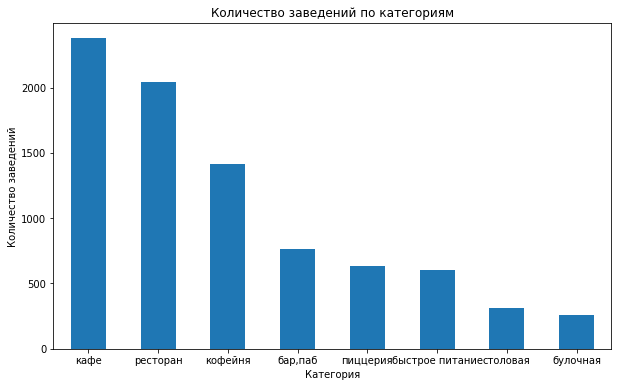

In [19]:
plt.figure(figsize=(10, 6))

df['category'].value_counts().plot(kind='bar', rot=0, legend=False, title=f'Количество заведений по категориям')

plt.xlabel('Категория')
plt.ylabel('Количество заведений')

plt.show()

На основе диаграммы можно сделать вывод, что больше всего заведений в категориях: кафе и ресторан, а меньше всего заведений в категориях: столовая и булочная.

<a id="Административные-районы-Москвы"></a>
### Задача 2

Рассмотрим, какие административные районы Москвы присутствуют в данных. Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводим столбчатыми диаграммами.

In [20]:
df['district'].unique()

array(['Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Западный административный округ',
       'Центральный административный округ',
       'Восточный административный округ',
       'Юго-Восточный административный округ',
       'Южный административный округ',
       'Юго-Западный административный округ'], dtype=object)

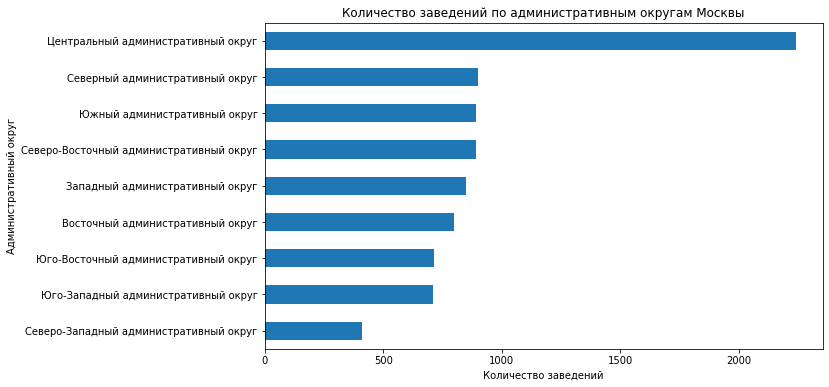

In [21]:
dist_counts = df['district'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
dist_counts.plot(kind='barh', rot=0)
plt.title('Количество заведений по административным округам Москвы')
plt.xlabel('Количество заведений')
plt.ylabel('Административный округ')

plt.show()

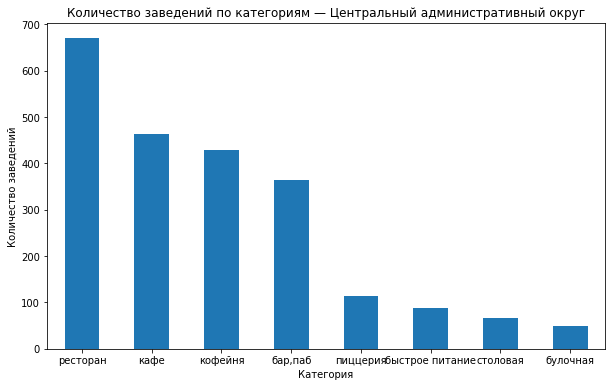

In [22]:
df_cao = df[df['district'] == 'Центральный административный округ']

plt.figure(figsize=(10, 6))

df_cao['category'].value_counts().plot(
    kind='bar',
    rot=0,
    legend=False,
    title='Количество заведений по категориям — Центральный административный округ'
)

plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.show()

Большинство заведений расположены в Центральном административном округе (более 2000), тогда как в Северо-Западном административном округе их менее 500. Рестораны лидируют с явным преимуществом по количеству заведений в ЦАО (более 600), а столовые, булочные и быстрое питание имеют наименьшее количество заведений (менее 100).

<a id="Сетевые-и-несетевые-заведения"></a>
### Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.

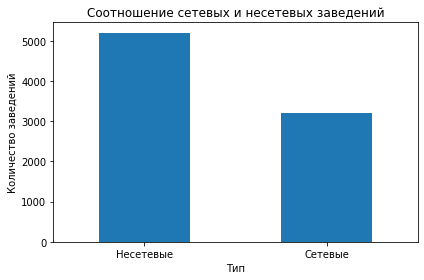

In [23]:
chain_map = {1: 'Сетевые', 0: 'Несетевые'}
chain_counts = df['chain'].map(chain_map).value_counts()

plt.figure(figsize=(6, 4))
chain_counts.plot(kind='bar', rot=0, title='Соотношение сетевых и несетевых заведений')
plt.xlabel('Тип')
plt.ylabel('Количество заведений')
plt.tight_layout()
plt.show()

Несетевые заведения явно преобладают.

<Figure size 720x432 with 0 Axes>

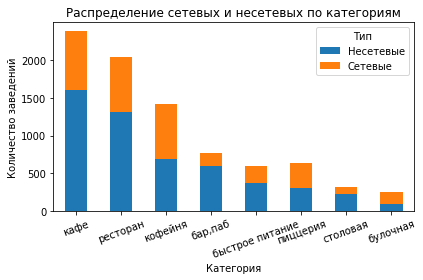

In [24]:
pivot_cat = df.pivot_table(index='category', columns='chain', values='id',
                           aggfunc='count', fill_value=0)

pivot_cat = pivot_cat.rename(columns={0: 'Несетевые', 1: 'Сетевые'})

pivot_cat = pivot_cat.sort_values(by=['Несетевые','Сетевые'], ascending=False)

plt.figure(figsize=(10, 6))
pivot_cat[['Несетевые','Сетевые']].plot(kind='bar', stacked=True, rot=20)
plt.title('Распределение сетевых и несетевых по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.legend(title='Тип')
plt.tight_layout()
plt.show()

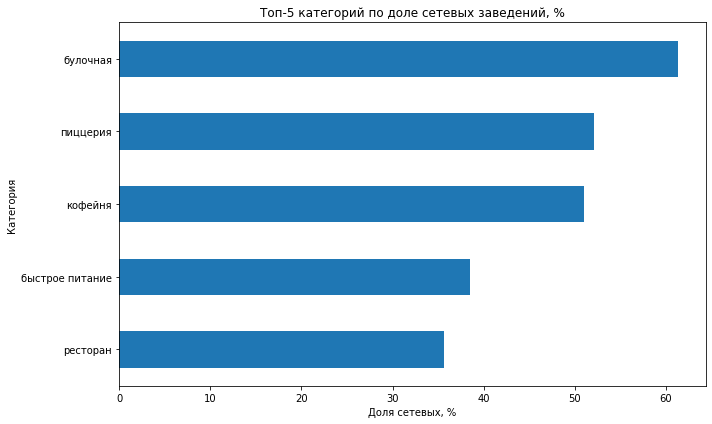

In [21]:
totals = pivot_cat['Несетевые'] + pivot_cat['Сетевые']
share_net = (pivot_cat['Сетевые'] / totals * 100).round(1)
share_net = share_net.sort_values(ascending=False)

top_n = 5
plt.figure(figsize=(10, 6))
share_net.head(top_n).plot(kind='barh')
plt.title(f'Топ-{top_n} категорий по доле сетевых заведений, %')
plt.xlabel('Доля сетевых, %')
plt.ylabel('Категория')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

На диаграмме выведены Топ-5 категорий по сетевым заведениям, среди них лидируют булочные (более 60%).

<a id="Количество-посадочных-мест"></a>
### Задача 4

Исследуем количество посадочных мест в заведениях.

In [25]:
df['seats'].describe()

count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

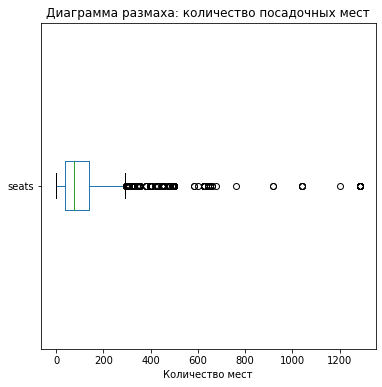

In [26]:
plt.figure(figsize=(6, 6))
df['seats'].dropna().plot(kind='box', vert=False)
plt.title('Диаграмма размаха: количество посадочных мест')
plt.xlabel('Количество мест')

plt.show()

- Медиана ≈ **75**, IQR: **40–140** ⇒ верхняя граница по 1.5×IQR ≈ **290**.
- Много значений **> 290** (макс **1288**) — правохвостные выбросы.
- Причины: **крупные площадки** (фуд-холлы/банкетные/столовые), **суммирование залов/летних террас**, **ошибки ввода** (лишний ноль).
- **0 мест** — точки «на вынос» или незаполненное поле.

In [27]:
med_per_cat = (
    df.dropna(subset=['seats'])
      .groupby('category', as_index=False)['seats']
      .median()
      .sort_values('seats', ascending=False)
)
med_per_cat

,category,seats
6,ресторан,86.0
0,"бар,паб",82.5
4,кофейня,80.0
7,столовая,75.5
2,быстрое питание,65.0
3,кафе,60.0
5,пиццерия,55.0
1,булочная,50.0


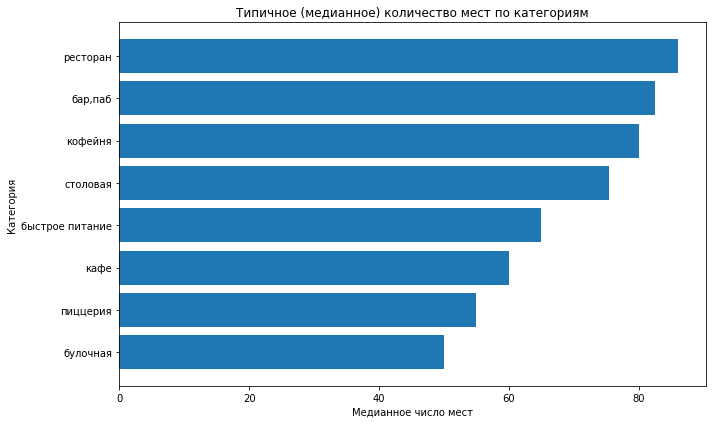

In [28]:
plt.figure(figsize=(10, 6))
plt.barh(med_per_cat['category'], med_per_cat['seats'])
plt.title('Типичное (медианное) количество мест по категориям')
plt.xlabel('Медианное число мест')
plt.ylabel('Категория')
plt.gca().invert_yaxis() 

plt.tight_layout()
plt.show()

Больше всего мест у ресторанов (86), далее бар/паб (82.5) и кофейни (80) — это более «заловые» форматы.

Средняя группа: столовые (75.5), быстрое питание (65), кафе (60).

Меньше всего у пиццерий (55) и булочных (50) — форматы с компактной посадкой.

<a id="Рейтинг-заведений"></a>
### Задача 5

Исследуем рейтинг заведений. Визуализируем распределение средних рейтингов по категориям заведений.

          category  mean_rating
0          бар,паб     4.387712
5         пиццерия     4.301264
6         ресторан     4.290357
4          кофейня     4.277282
1         булочная     4.268359
7         столовая     4.211429
3             кафе     4.123886
2  быстрое питание     4.050249


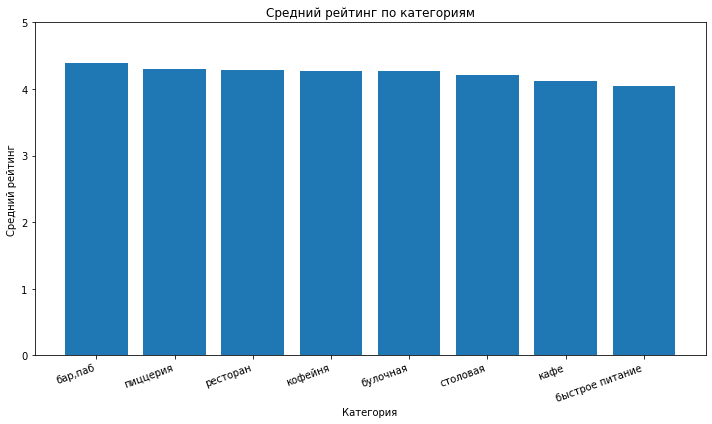

In [29]:
mean_per_cat = (
    df.groupby('category', as_index=False)['rating']
      .mean()
      .rename(columns={'rating': 'mean_rating'})
      .sort_values('mean_rating', ascending=False)
)

print(mean_per_cat)

plt.figure(figsize=(10, 6))
plt.bar(mean_per_cat['category'], mean_per_cat['mean_rating'])
plt.title('Средний рейтинг по категориям')
plt.xlabel('Категория')
plt.ylabel('Средний рейтинг')
plt.ylim(0, 5)
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

- **Топ-3:** бар/паб — **4.39**, пиццерия — **4.30**, ресторан — **4.29**.  
- **Ниже остальных:** быстрое питание — **4.05**, кафе — **4.12**.  
- **Общий уровень высок:** диапазон **4.05–4.39**, разница между макс и мин — **0.34** балла → **умеренные различия**.  
- **Интерпретация:** более «атмосферные/полноформатные» форматы (бар/паб, ресторан) получают чуть более высокие оценки.

<a id="Корреляция рейтингов с другими признаками"></a>
### Задача 6

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. Построим и визуализируем матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберем самую сильную связь и проверим её.

In [30]:
sub = df[['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']].copy()

sub['is_24_7'] = sub['is_24_7'].fillna(False).astype(bool)
sub['category'] = sub['category'].astype('category')
sub['district'] = sub['district'].astype('category')
sub['price'] = sub['price'].astype('category')
sub['chain'] = sub['chain'].astype('category')

corr = sub.phik_matrix(interval_cols=['rating', 'seats'])
corr

,rating,category,district,chain,seats,price,is_24_7
rating,1.000000,0.190003,0.200691,0.108092,0.000000,0.220295,0.150173
category,0.190003,1.000000,0.174326,0.265627,0.048186,0.566933,0.244789
district,0.200691,0.174326,1.000000,0.064233,0.352496,0.202787,0.076392
chain,0.108092,0.265627,0.064233,1.000000,0.056563,0.218211,0.043414
seats,0.000000,0.048186,0.352496,0.056563,1.000000,0.065308,0.043278
price,0.220295,0.566933,0.202787,0.218211,0.065308,1.000000,0.084183
is_24_7,0.150173,0.244789,0.076392,0.043414,0.043278,0.084183,1.000000


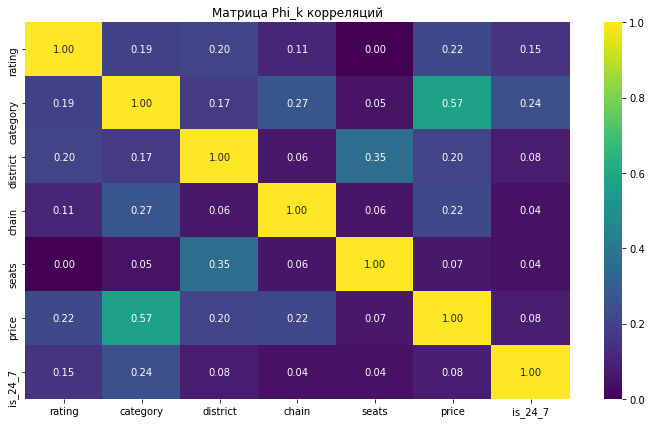

In [31]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr.loc[sub.columns, sub.columns], annot=True, fmt='.2f', vmin=0, vmax=1, cmap='viridis')
plt.title('Матрица Phi_k корреляций')
plt.tight_layout()
plt.show()

Самая сильная корреляция наблюдается между рейтингом заведения и прайсом.

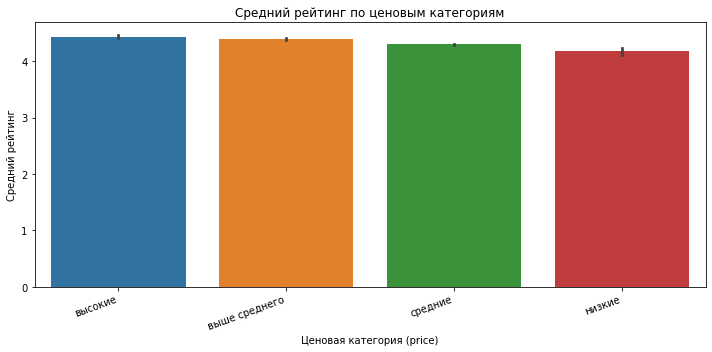

In [32]:
sub = df[['price', 'rating']].dropna()
order = sub.groupby('price')['rating'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
sns.barplot(data=sub, x='price', y='rating', order=order)
plt.title('Средний рейтинг по ценовым категориям')
plt.xlabel('Ценовая категория (price)')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

Действительно, наблюдается корреляция между средним рейтингом заведения и ценовой категорией: чем выше ценовая категория, тем выше рейтинг заведения (но связь слабая).

<a id="Популярные-сети-Москвы"></a>
### Задача 7

Сгруппируем данные по названиям заведений и найдём топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе.

In [33]:
chains = df[df['chain'] == 1].copy()

base = (
    chains.groupby('name', as_index=False)
          .agg(outlets=('id', 'count'),
               mean_rating=('rating', 'mean'))
)

cat_counts = (
    chains.groupby(['name', 'category'], as_index=False)
          .size()
          .rename(columns={'size': 'cnt'})
)

top_cat = (
    cat_counts.sort_values(['name', 'cnt'], ascending=[True, False])
              .drop_duplicates(subset='name')[['name', 'category']]
              .rename(columns={'category': 'top_category'})
)

res = base.merge(top_cat, on='name', how='left')
res['mean_rating'] = res['mean_rating'].round(2)

top_n = 15
top15 = res.sort_values('outlets', ascending=False).head(top_n)

top15.rename(columns={'name': 'brand'})

,brand,outlets,mean_rating,top_category
746,Шоколадница,120,4.18,кофейня
344,Домино'с Пицца,76,4.17,пиццерия
340,Додо Пицца,74,4.29,пиццерия
148,One Price Coffee,71,4.06,кофейня
759,Яндекс Лавка,69,3.87,ресторан
59,Cofix,65,4.08,кофейня
170,Prime,50,4.12,ресторан
679,Хинкальная,44,4.32,кафе
378,КОФЕПОРТ,42,4.15,кофейня
431,Кулинарная лавка братьев Караваевых,39,4.39,кафе


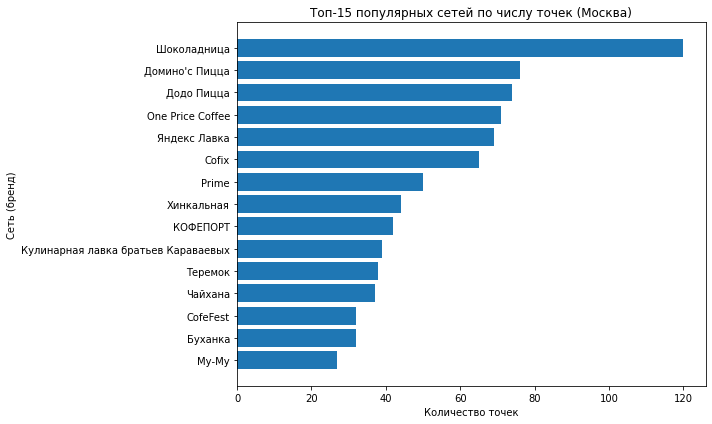

In [34]:
plt.figure(figsize=(10, 6))
plt.barh(top15['name'], top15['outlets'])
plt.title(f'Топ-{top_n} популярных сетей по числу точек (Москва)')
plt.xlabel('Количество точек')
plt.ylabel('Сеть (бренд)')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

- **Лидеры по числу точек:** Шоколадница (120), Domino’s Pizza (76), Додо Пицца (74).
- **Категории в топ-15:** преобладают **кофейни** и **пиццерии**.
- **Высшие рейтинги:** Буханка (4.40), Караваевы (4.39), Хинкальная (4.32), Додо Пицца (4.29).
- **Нижние рейтинги:** Яндекс Лавка (3.87), Чайхана (3.92).
- Общий уровень высок: ~**3.9–4.4** по среднему рейтингу.

<a id="Средний-чек-по-районам-Москвы"></a>
### Задача 8

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других.

In [35]:
sub = df[['district', 'middle_avg_bill']].dropna()
med_by_dist = (
    sub.groupby('district', as_index=False)['middle_avg_bill']
       .median()
       .rename(columns={'middle_avg_bill': 'median_bill'})
       .sort_values('median_bill', ascending=False)
)

med_by_dist

,district,median_bill
1,Западный административный округ,1000.0
5,Центральный административный округ,1000.0
4,Северо-Западный административный округ,700.0
2,Северный административный округ,650.0
7,Юго-Западный административный округ,600.0
0,Восточный административный округ,575.0
3,Северо-Восточный административный округ,500.0
8,Южный административный округ,500.0
6,Юго-Восточный административный округ,450.0


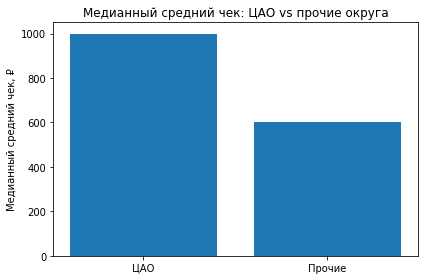

In [36]:
CAO = 'Центральный административный округ'
is_cao = sub['district'] == CAO
med_cao = sub.loc[is_cao, 'middle_avg_bill'].median()
med_non = sub.loc[~is_cao, 'middle_avg_bill'].median()

plt.figure(figsize=(6, 4))
plt.bar(['ЦАО', 'Прочие'], [med_cao, med_non])
plt.title('Медианный средний чек: ЦАО vs прочие округа')
plt.ylabel('Медианный средний чек, ₽')

plt.tight_layout()
plt.show()

В целом наблюдается спад цен по мере удаления от центра: центр (и примыкающий к нему ЗАО) — самые дорогие, далее уровни снижаются до **450–700 ₽** на периферии.

<a id="Промежуточный-вывод-2"></a>
### Промежуточный вывод

- **Категории.** Больше всего — *кафе* и *рестораны*; меньше всего — *столовые* и *булочные*.  
- **Округа.** В данных 9 АО; больше всего заведений в **ЦАО** (≈2k+), меньше — в **СЗАО** (<500). В ЦАО структура категорий схожа с общей: лидируют кафе/рестораны.
- **Сетевость.** В целом преобладают **несетевые**. По доле сетевых лидируют **булочные** (>60%).
- **Посадочные места.** Медиана **75**, IQR **40–140**; выбросы >**290** (макс **1288**) — крупные площадки/объединённые залы/ошибки. Типичные места (медиана): ресторан **86**, бар/паб **82.5**, кофейня **80**, столовая **75.5**, быстрое питание **65**, кафе **60**, пиццерия **55**, булочная **50**.
- **Рейтинги по категориям.** Топ: бар/паб **4.39**, пиццерия **4.30**, ресторан **4.29**; ниже: быстрое питание **4.05**, кафе **4.12**. Разброс средних небольшой (**~0.34**).
- **Корреляции (Phi_k).** Самая заметная связь рейтинга — с **ценовой категорией** `price` (**~0.22**, слабая/умеренная, но положительная). Остальные слабее.
- **Топ-сети.** По числу точек лидируют: **Шоколадница (120)**, **Domino’s (76)**, **Додо Пицца (74)**. В топ-15 доминируют **кофейни** и **пиццерии**. По рейтингам среди них выше: **Буханка (4.40)**, **Караваевы (4.39)**.
- **Средний чек по округам.** **ЦАО** и **ЗАО** — самые дорогие (медиана **~1000 ₽**), на периферии **450–700 ₽**. В целом: **чем дальше от центра, тем дешевле**, но тренд не строго монотонный.

<a id="Итоговый вывод и рекомендации"></a>
## Итоговый вывод и рекомендации 

<a id="Общий-обзор-проделанной-работы"></a>
### Общий обзор проделанной работы

- Объединены два датасета (8 406 объектов, 13 полей), выполнена предобработка (проверка типов, пропусков, дублей), сформирован признак `is_24_7`.
- Проведён EDA по ключевым направлениям: категории, округа, сетевость, посадочные места, рейтинги, цены и топ-сети.
- Для смешанных признаков рассчитаны корреляции с рейтингом методом **Phi_k**; визуализированы распределения и зависимости.

<a id="Основные-выводы-по-результатам-анализа"></a>
### Основные выводы по результатам анализа

- **Категории и структура рынка.** Больше всего **кафе** и **ресторанов**; меньше — **столовых** и **булочных**.  
- **География.** Больше всего заведений в **ЦАО** (>2 000), меньше — в **СЗАО** (<500).  
- **Сетевость.** В целом преобладают **несетевые**; по доле сетевых лидируют **булочные** (>60%).  
- **Посадочные места.** «Типичный» размер — **~75 мест** (IQR: 40–140); выбросы >290 мест связаны с крупными площадками/объединёнными залами. Медианы по категориям, мест: ресторан **86**, бар/паб **82.5**, кофейня **80**, столовая **75.5**, fast food **65**, кафе **60**, пиццерия **55**, булочная **50**.  
- **Рейтинги по категориям.** Топ: **бар/паб (≈4.39)**, **пиццерия (≈4.30)**, **ресторан (≈4.29)**; ниже: **fast food (≈4.05)** и **кафе (≈4.12)**. Разница невелика (~0.34).  
- **Корреляции с рейтингом.** Самая заметная связь — с **ценовой категорией** `price` (**Phi_k ≈ 0.22**): чем выше ценовой сегмент, тем выше средний рейтинг (слабая/умеренная зависимость).  
- **Популярные сети.** По числу точек лидируют: **Шоколадница (120)**, **Domino’s (76)**, **Додо Пицца (74)**. В топ-15 доминируют **кофейни** и **пиццерии**; самые высокие средние рейтинги среди топ-сетей: **Буханка (4.40)**, **Караваевы (4.39)**, **Хинкальная (4.32)**.  
- **Цены по округам.** **ЦАО** и **ЗАО** — самые дорогие (медианный чек ≈ **1 000 ₽**); на периферии — **450–700 ₽**. В целом наблюдается понижение чеков по мере удаления от центра (тренд не строго монотонный).  

<a id="Рекомендации-для-заказчика"></a>
### Рекомендации для заказчика

**Формат**
1. **Кофейня/булочная** (компактный формат, 50–80 мест): высокий спрос и устойчивая сетевость; быстрый масштабируемый формат. Рейтинг у кофеен стабильно высокий (≈4.28), у булочных — тоже (≈4.27–4.40 у лидеров).
2. **Пиццерия** (≈55 мест) — сильные сети и хорошие рейтинги; уместен акцент на доставку и трафик «семья/офис».
3. **Бар/паб** (≈82.5 мест) — самые высокие рейтинги; требует локаций с вечерним трафиком и событийной повесткой.

**Локация**
- Для премиальных концепций — **ЦАО/ЗАО**: выше медианный чек (~1 000 ₽) и готовность платить.    
- Внутри округов — целиться в кластеры трафика: ТЦ/бизнес-кварталы/рядом с метро и вузами.

**Ценовая политика и качество**
- Корреляция рейтинга с `price` положительная (Phi_k ≈ 0.22): **умеренно более высокий чек** при улучшении сервиса/качества не «штрафует» по оценкам, а может их повысить. Сделать ставку на продукт/сервис и понятную ценовую лестницу (base/plus/premium).

**Операционная конфигурация**
- Держать посадку в «типичных» коридорах для формата (кофейня 60–90, ресторан 80–120), избегать чрезмерных площадей.  
- Рассмотреть **расширенный график** (до позднего вечера) в ЦАО/транспортных узлах: 24/7 сейчас редкость (~9%), есть окно возможностей.

**Масштабирование и тесты** 
- Для сетевых планов — начинать с **кофейни/булочной или пиццерии**: высокая повторяемость, сильные референсы по рынку, устойчивые рейтинги.